In [10]:
git clone https://github.com/lforey/Projet_ALSTOM.git
cd Projet_ALSTOM

SyntaxError: invalid syntax (2177428277.py, line 1)

In [1]:
import zipfile
import pandas as pd
import os

zip_file_path = 'metropt+3+dataset.zip'
extract_path = 'data'  # dossier local

# Crée le dossier s'il n'existe pas
os.makedirs(extract_path, exist_ok=True)

# Extraction
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"'{zip_file_path}' unzipped to '{extract_path}'.")

try:
    csv_path = os.path.join(extract_path, 'MetroPT3(AirCompressor).csv')
    df = pd.read_csv(csv_path)

    print("\nDataFrame 'df' loaded successfully.")
    print("\nFirst 5 rows of the DataFrame:")
    print(df.head())

    print("\nDataFrame Information:")
    df.info()

except FileNotFoundError:
    print("FileNotFoundError: CSV file not found.")
except Exception as e:
    print(f"An error occurred: {e}")

'metropt+3+dataset.zip' unzipped to 'data'.

DataFrame 'df' loaded successfully.

First 5 rows of the DataFrame:
   Unnamed: 0            timestamp    TP2    TP3     H1  DV_pressure  \
0           0  2020-02-01 00:00:00 -0.012  9.358  9.340       -0.024   
1          10  2020-02-01 00:00:10 -0.014  9.348  9.332       -0.022   
2          20  2020-02-01 00:00:19 -0.012  9.338  9.322       -0.022   
3          30  2020-02-01 00:00:29 -0.012  9.328  9.312       -0.022   
4          40  2020-02-01 00:00:39 -0.012  9.318  9.302       -0.022   

   Reservoirs  Oil_temperature  Motor_current  COMP  DV_eletric  Towers  MPG  \
0       9.358           53.600         0.0400   1.0         0.0     1.0  1.0   
1       9.348           53.675         0.0400   1.0         0.0     1.0  1.0   
2       9.338           53.600         0.0425   1.0         0.0     1.0  1.0   
3       9.328           53.425         0.0400   1.0         0.0     1.0  1.0   
4       9.318           53.475         0.0400   1.0   

In [2]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1516948 entries, 0 to 1516947
Data columns (total 17 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   Unnamed: 0       1516948 non-null  int64         
 1   timestamp        1516948 non-null  datetime64[ns]
 2   TP2              1516948 non-null  float64       
 3   TP3              1516948 non-null  float64       
 4   H1               1516948 non-null  float64       
 5   DV_pressure      1516948 non-null  float64       
 6   Reservoirs       1516948 non-null  float64       
 7   Oil_temperature  1516948 non-null  float64       
 8   Motor_current    1516948 non-null  float64       
 9   COMP             1516948 non-null  float64       
 10  DV_eletric       1516948 non-null  float64       
 11  Towers           1516948 non-null  float64       
 12  MPG              1516948 non-null  float64       
 13  LPS              1516948 non-null  float64       
 14  Pr

In [3]:
print(df.isnull().sum())

Unnamed: 0         0
timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
COMP               0
DV_eletric         0
Towers             0
MPG                0
LPS                0
Pressure_switch    0
Oil_level          0
Caudal_impulses    0
dtype: int64


## Exploration of potentially relevant columns

`TP2`, `TP3`, `DV_pressure`, `Reservoirs`, `LPS`, `Pressure_switch`, and `Caudal_impulses`


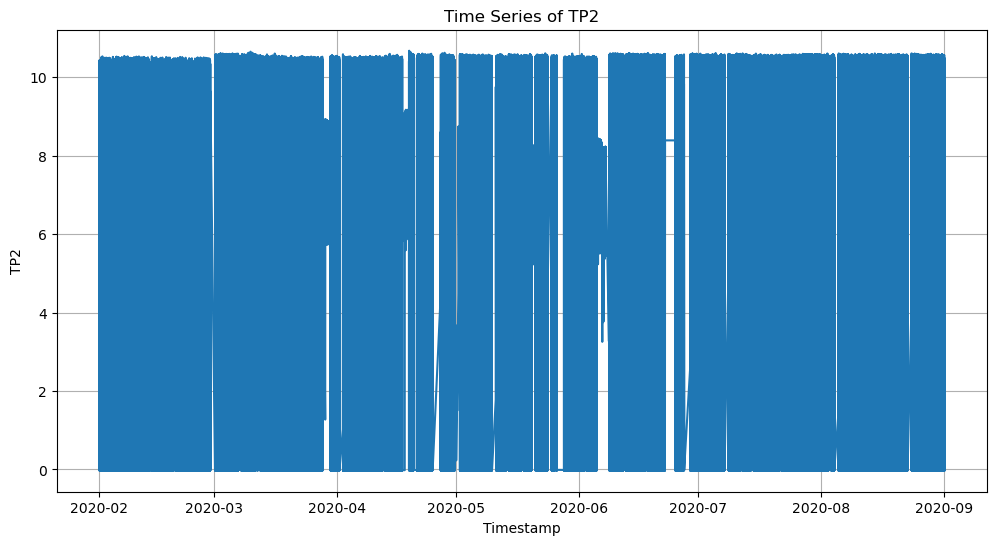

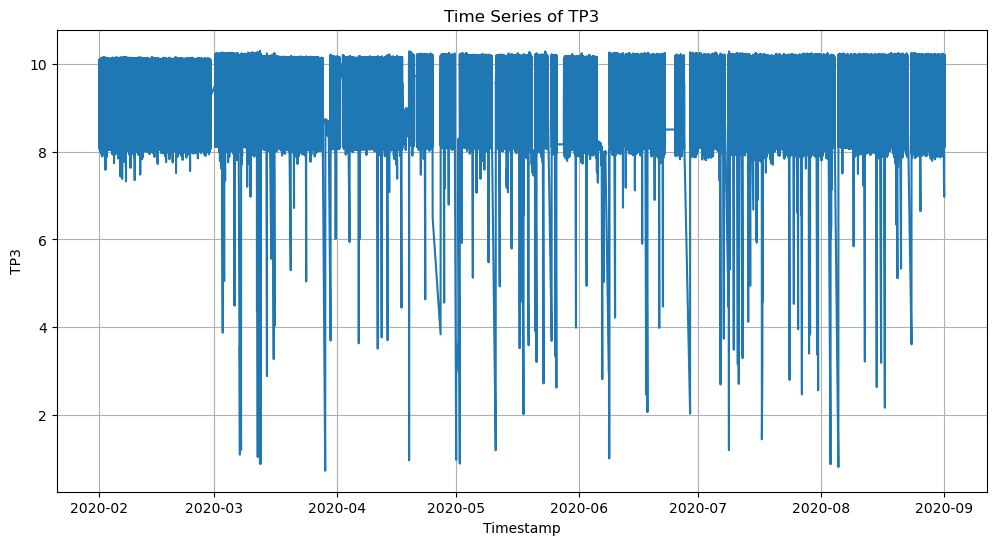

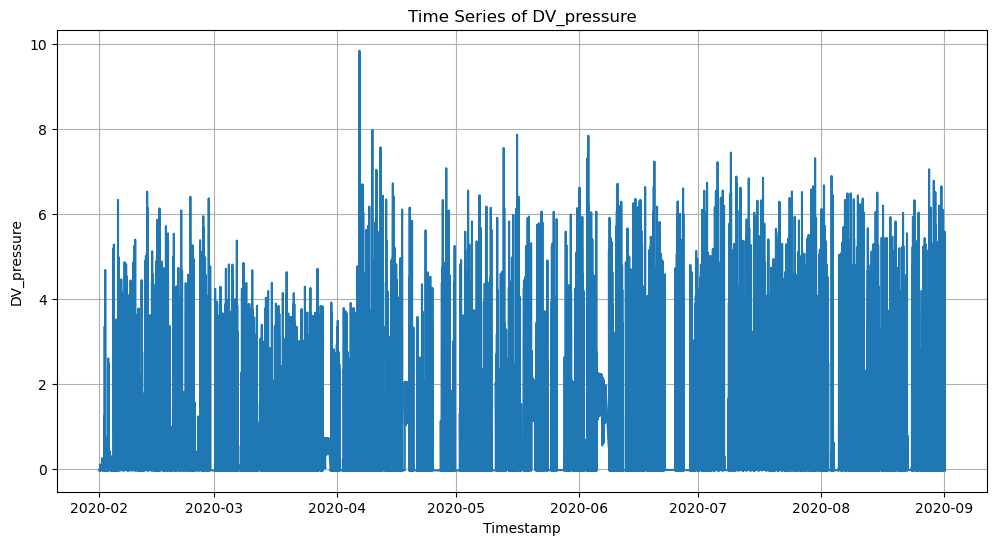

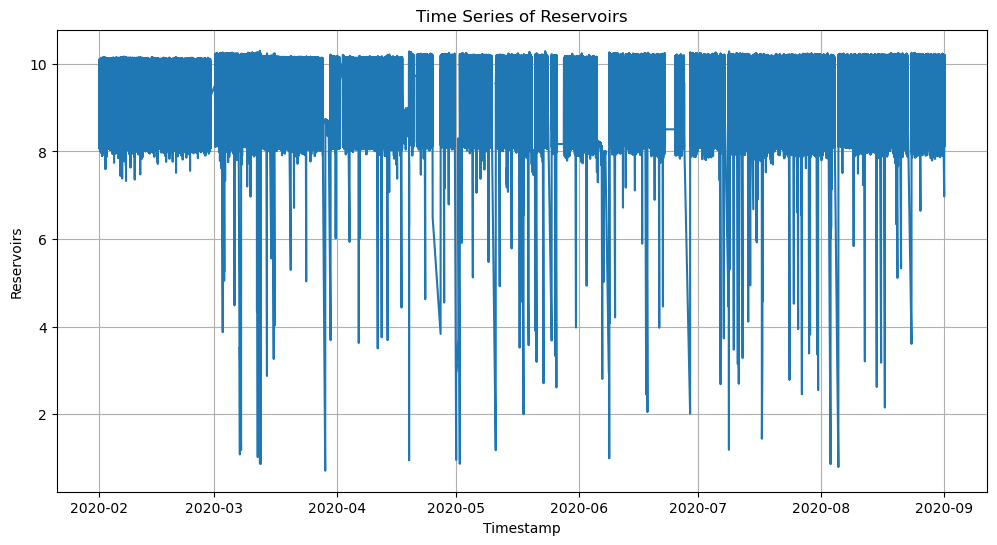

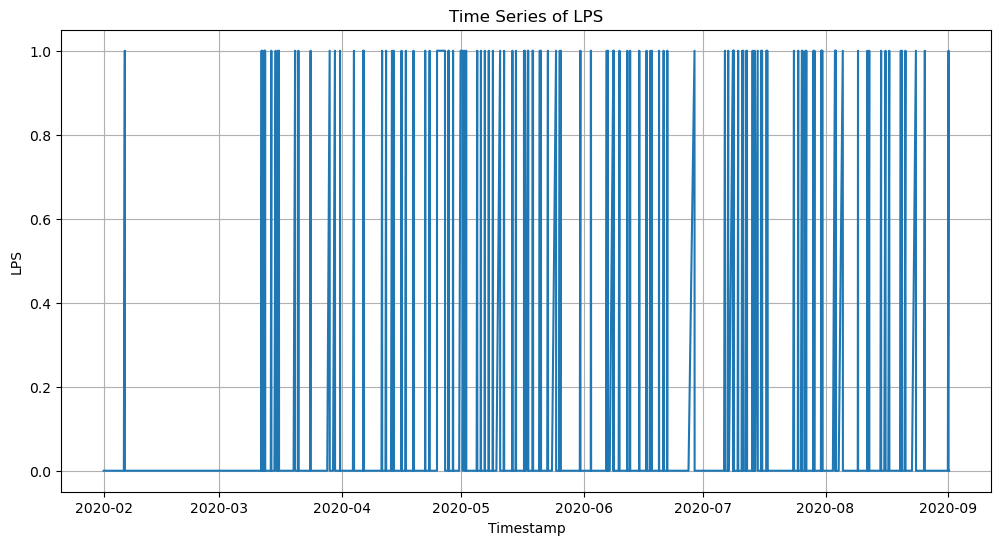

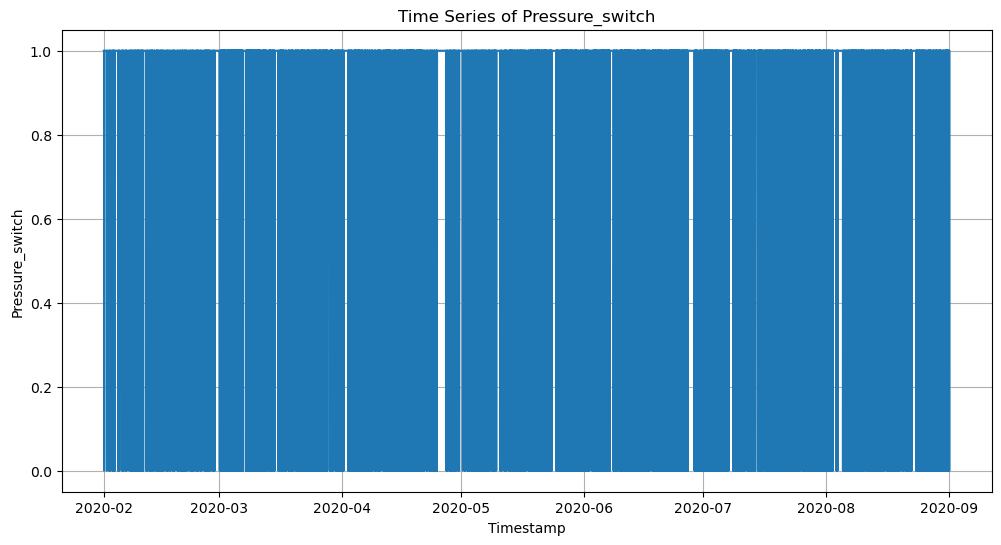

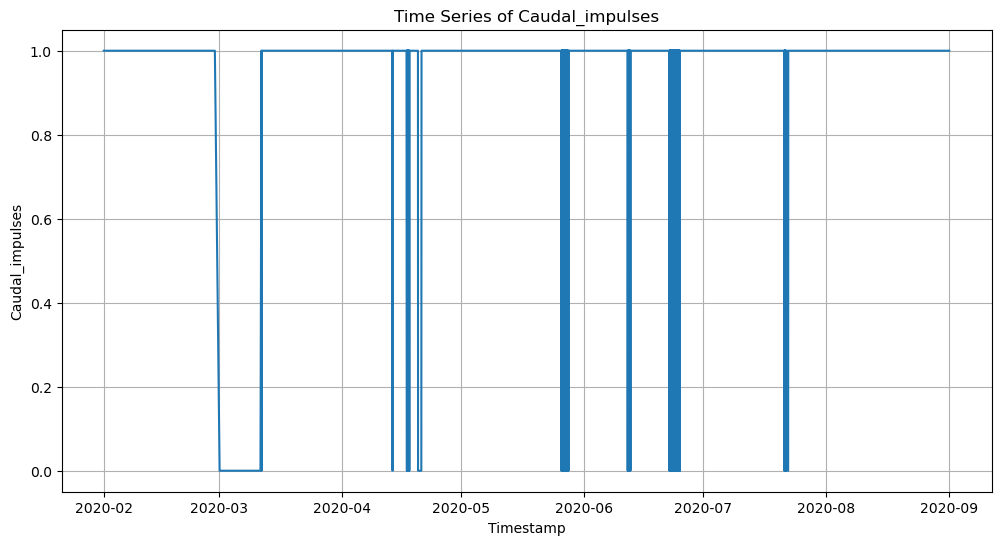

Time series plots generated for selected columns.


In [4]:
import matplotlib.pyplot as plt

columns_to_plot = ['TP2', 'TP3', 'DV_pressure', 'Reservoirs', 'LPS', 'Pressure_switch', 'Caudal_impulses']

for column in columns_to_plot:
    plt.figure(figsize=(12, 6))
    plt.plot(df['timestamp'], df[column])
    plt.xlabel('Timestamp')
    plt.ylabel(column)
    plt.title(f'Time Series of {column}')
    plt.grid(True)
    plt.show()
print("Time series plots generated for selected columns.")

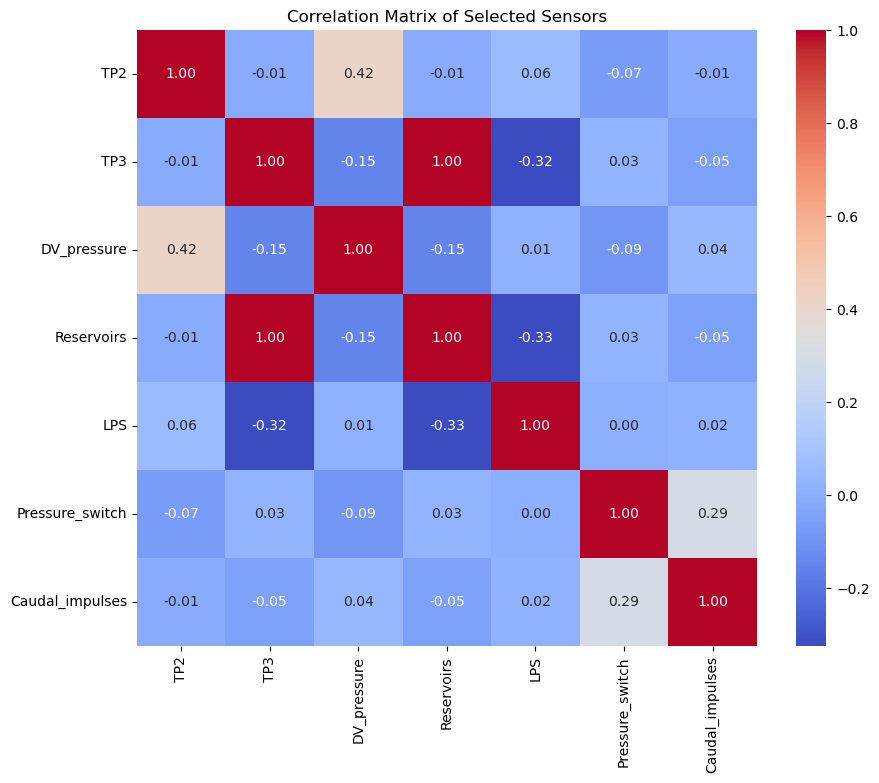

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

columns_for_correlation = ['TP2', 'TP3', 'DV_pressure', 'Reservoirs', 'LPS', 'Pressure_switch', 'Caudal_impulses']
correlation_matrix = df[columns_for_correlation].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Selected Sensors')
plt.show()

We can see that Reservoirs and TP3 are correlated so we can remove one of them before pursuing

In [6]:
columns_to_engineer = ['TP2', 'DV_pressure', 'LPS', 'Pressure_switch', 'Caudal_impulses', 'TP3']

df_features = pd.DataFrame()

window_size = 50

for col in columns_to_engineer:
    # Rolling standard deviation
    df_features[f'{col}_rolling_std'] = df[col].rolling(window=window_size).std()

    # Rolling median
    rolling_median = df[col].rolling(window=window_size).median()

    # Rolling residual
    df_features[f'{col}_rolling_residual'] = df[col] - rolling_median

# Drop rows with NaN values resulting from rolling calculations
df_features.dropna(inplace=True)

print("Engineered features DataFrame created and NaN values handled.")
print("First 5 rows of df_features:")
print(df_features.head())
print("df_features Info:")
df_features.info()

Engineered features DataFrame created and NaN values handled.
First 5 rows of df_features:
    TP2_rolling_std  TP2_rolling_residual  DV_pressure_rolling_std  \
49         0.001007                -0.002                 0.000997   
50         0.001009                -0.002                 0.000990   
51         0.001007                 0.000                 0.000997   
52         0.001009                -0.002                 0.000997   
53         0.001010                -0.001                 0.000997   

    DV_pressure_rolling_residual  LPS_rolling_std  LPS_rolling_residual  \
49                        -0.002              0.0                   0.0   
50                         0.000              0.0                   0.0   
51                        -0.002              0.0                   0.0   
52                         0.000              0.0                   0.0   
53                         0.000              0.0                   0.0   

    Pressure_switch_rolling_std  Pres

## Train Isolation Forest on Data Before April 1st and Set Threshold

Split the engineered features DataFrame into a training set containing all data points with timestamps before April 1st, and a prediction set containing the remaining data.

In [7]:
df_merged_features = df.loc[df_features.index].copy()
df_merged_features = pd.concat([df_merged_features, df_features], axis=1)

print("Merged DataFrame 'df_merged_features' created.")
print("First 5 rows of df_merged_features:")
print(df_merged_features.head())
print("df_merged_features Info:")
df_merged_features.info()

Merged DataFrame 'df_merged_features' created.
First 5 rows of df_merged_features:
    Unnamed: 0           timestamp    TP2    TP3     H1  DV_pressure  \
49         490 2020-02-01 00:08:06 -0.014  8.862  8.850       -0.024   
50         500 2020-02-01 00:08:15 -0.014  8.854  8.840       -0.022   
51         510 2020-02-01 00:08:25 -0.012  8.846  8.830       -0.024   
52         520 2020-02-01 00:08:35 -0.014  8.836  8.820       -0.022   
53         530 2020-02-01 00:08:45 -0.014  8.826  8.812       -0.022   

    Reservoirs  Oil_temperature  Motor_current  COMP  ...  \
49       8.866           52.650         0.0400   1.0  ...   
50       8.856           52.725         0.0400   1.0  ...   
51       8.848           52.575         0.0400   1.0  ...   
52       8.838           52.600         0.0425   1.0  ...   
53       8.828           52.500         0.0400   1.0  ...   

    DV_pressure_rolling_std  DV_pressure_rolling_residual  LPS_rolling_std  \
49                 0.000997            

In [8]:
import pandas as pd
from sklearn.ensemble import IsolationForest

# Split data into training and prediction sets
df_train = df_merged_features[df_merged_features['timestamp'] < '2020-04-01'].copy()
df_predict = df_merged_features[df_merged_features['timestamp'] >= '2020-04-01'].copy()

# Define the feature columns for the Isolation Forest model (excluding 'timestamp', 'anomaly_score', 'anomaly_label', and original columns)
feature_columns = [col for col in df_features.columns if col not in ['anomaly_score', 'anomaly_label']]

X_train = df_train[feature_columns]

model = IsolationForest(contamination=0.001, random_state=42, n_estimators=100)

model.fit(X_train)

train_anomaly_scores = model.decision_function(X_train)

anomaly_threshold = max(train_anomaly_scores) * 1.25

print(f"Data split into training (before 2020-04-01) and prediction sets.")
print(f"Training data shape: {df_train.shape}")
print(f"Prediction data shape: {df_predict.shape}")
print(f"Isolation Forest model trained on training data.")
print(f"Calculated anomaly threshold: {anomaly_threshold}")

Data split into training (before 2020-04-01) and prediction sets.
Training data shape: (445249, 29)
Prediction data shape: (1071650, 29)
Isolation Forest model trained on training data.
Calculated anomaly threshold: 0.491144933477324


Total number of anomalies detected in the full dataset: 1651


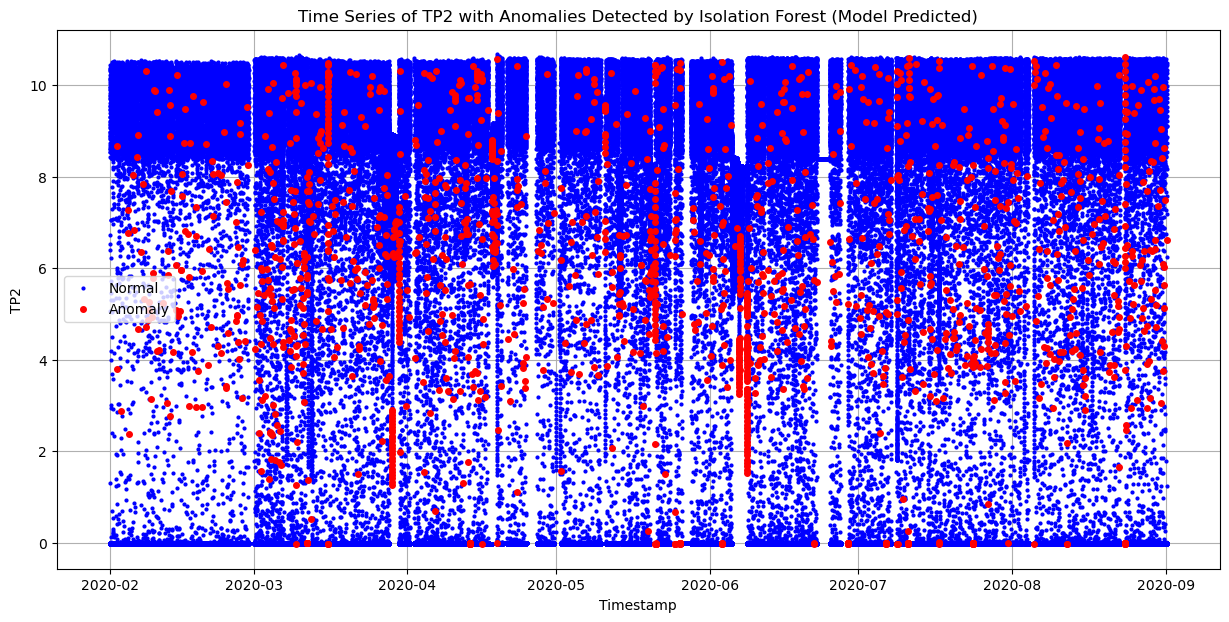

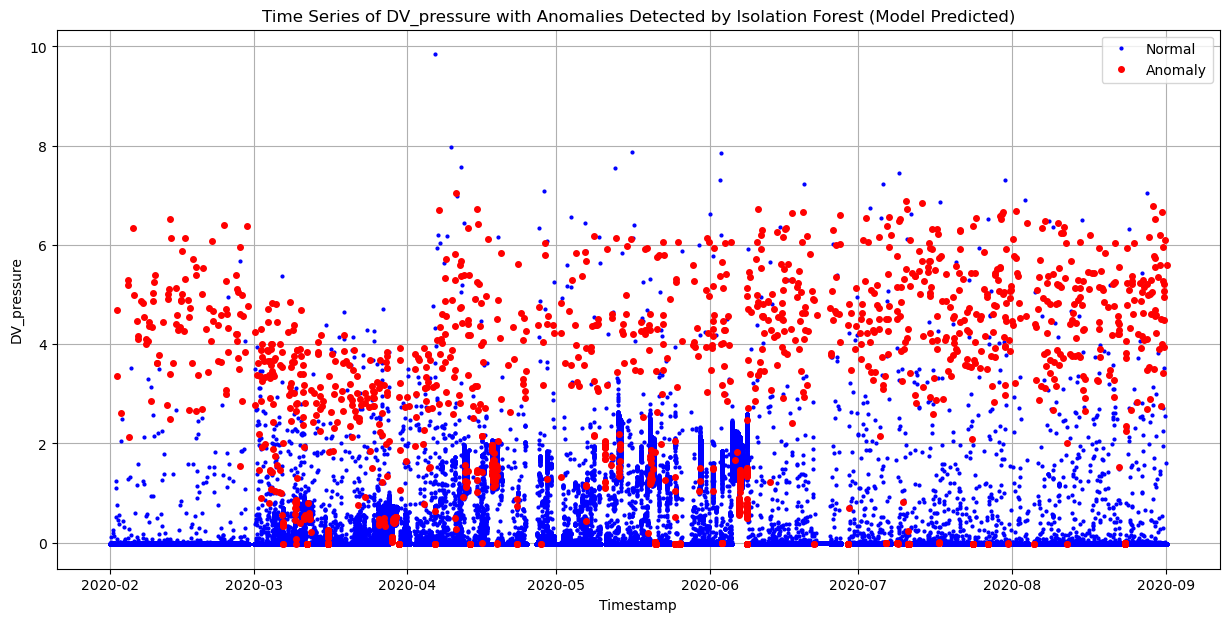

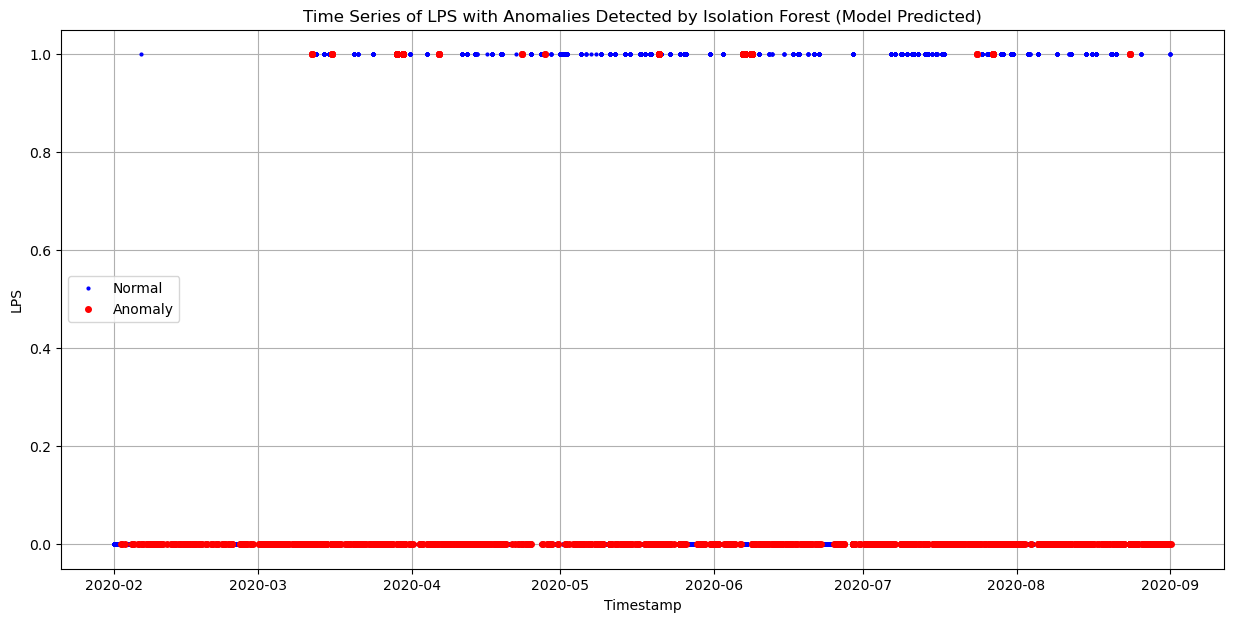

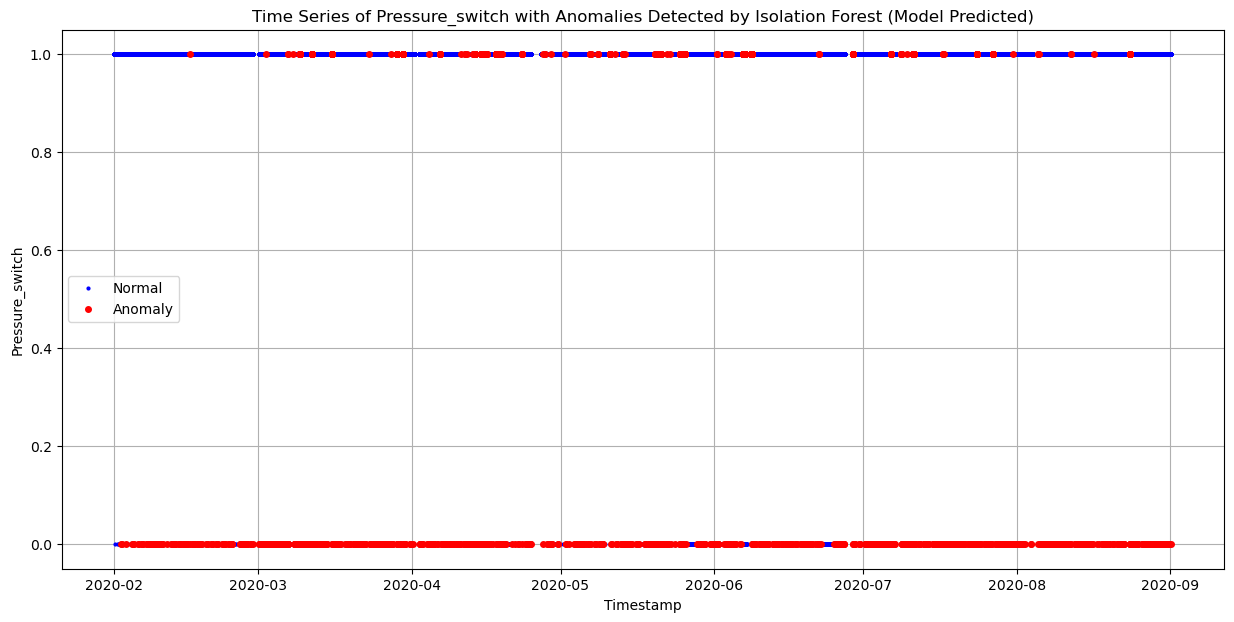

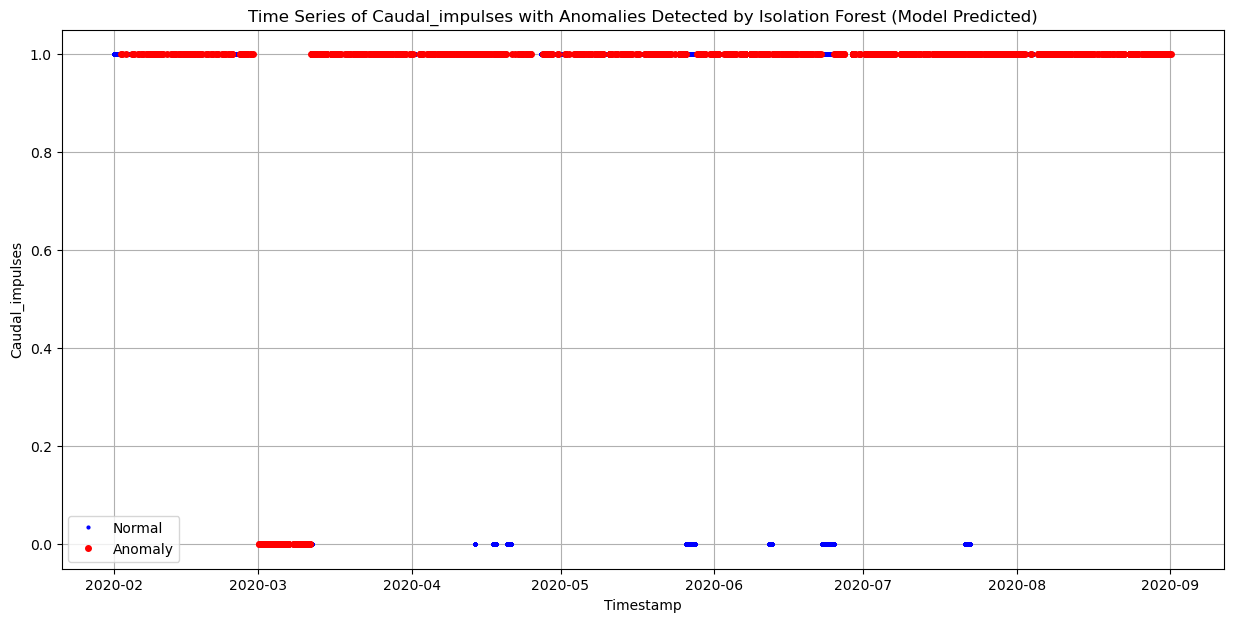

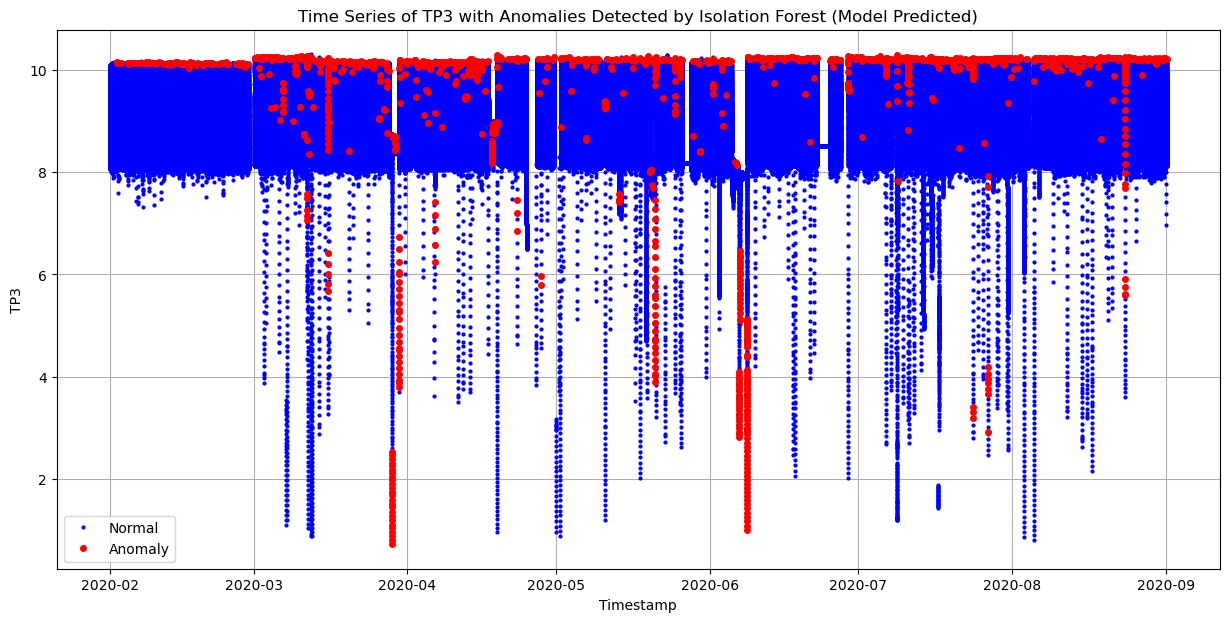

Anomaly visualization plots generated for selected columns using the model's internal threshold.


In [9]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Predict anomaly labels for the entire df_merged_features using the trained model
# IsolationForest's predict method returns -1 for outliers and 1 for inliers.
full_anomaly_labels = model.predict(df_merged_features[feature_columns])

# Store these predicted anomaly labels in a new column named 'is_anomaly'
# Convert -1 (anomaly) to 1, and 1 (normal) to 0 for consistent plotting logic.
df_merged_features['is_anomaly'] = (full_anomaly_labels == -1).astype(int)

# Identify anomalies (where 'is_anomaly' is 1)
num_total_anomalies = df_merged_features['is_anomaly'].sum()
print(f"Total number of anomalies detected in the full dataset: {num_total_anomalies}")

# Define a list of original columns to visualize
columns_to_visualize = ['TP2', 'DV_pressure', 'LPS', 'Pressure_switch', 'Caudal_impulses', 'TP3']

for col in columns_to_visualize:
    plt.figure(figsize=(15, 7))

    # Plot normal points
    plt.plot(df_merged_features[df_merged_features['is_anomaly'] == 0]['timestamp'],
             df_merged_features[df_merged_features['is_anomaly'] == 0][col],
             'o', markersize=2, color='blue', label='Normal')

    # Plot anomalous points
    plt.plot(df_merged_features[df_merged_features['is_anomaly'] == 1]['timestamp'],
             df_merged_features[df_merged_features['is_anomaly'] == 1][col],
             'o', markersize=4, color='red', label='Anomaly')

    plt.title(f'Time Series of {col} with Anomalies Detected by Isolation Forest (Model Predicted)')
    plt.xlabel('Timestamp')
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.show()

print("Anomaly visualization plots generated for selected columns using the model's internal threshold.")